# Food Delivery Business Performance — Visualization Portfolio

A visualization-driven exploration of a food delivery business's performance using Matplotlib and Seaborn. Each chart is chosen to investigate a specific question — trends over time, differences across cities/cuisines, relationships between spend/delivery time and outcomes, and the effect of weather and order channel — with a short interpretation following each plot.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (360, 16)
<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    str           
 1   Date                     360 non-null    datetime64[us]
 2   Month                    360 non-null    str           
 3   Day                      360 non-null    str           
 4   City                     360 non-null    str           
 5   Cuisine                  360 non-null    str           
 6   Order_Channel            360 non-null    str           
 7   Weather                  360 non-null    str           
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 n

In [3]:
df.describe()

,Date,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,2025-06-30 21:32:00,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
min,2025-01-02 00:00:00,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,2025-04-05 12:00:00,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,2025-06-26 12:00:00,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,2025-09-25 12:00:00,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,2025-12-28 00:00:00,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000
std,NaN,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472


## 2. Orders and Revenue Over Time (Line Plot)

A line plot is well suited to showing how a metric evolves over time. Here we aggregate daily records by month to see the overall trend in total orders and total revenue across the year.

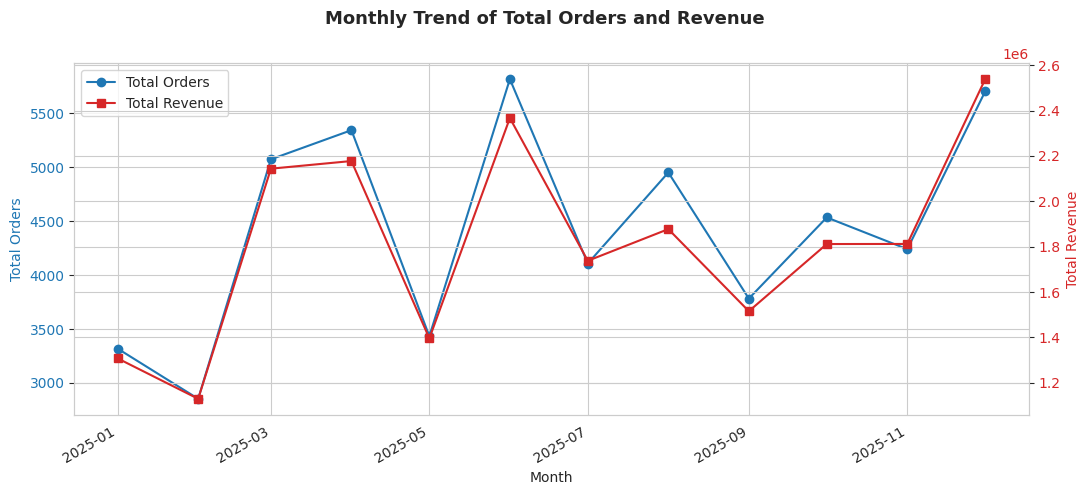

In [4]:
monthly = df.groupby(df["Date"].dt.to_period("M")).agg(
    Total_Orders=("Orders", "sum"),
    Total_Revenue=("Revenue", "sum")
).reset_index()
monthly["Date"] = monthly["Date"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(monthly["Date"], monthly["Total_Orders"], marker="o", color="tab:blue", label="Total Orders")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Orders", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(monthly["Date"], monthly["Total_Revenue"], marker="s", color="tab:red", label="Total Revenue")
ax2.set_ylabel("Total Revenue", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("Monthly Trend of Total Orders and Revenue", fontsize=13, fontweight="bold")
fig.autofmt_xdate()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

**Interpretation:** Orders and revenue move closely together across the months, which is expected since revenue is largely order-driven. Any month where the two lines diverge noticeably would suggest a change in average order value (e.g. more discounting or higher-priced orders) rather than a pure change in demand.

## 3. Total Revenue by City (Bar Chart)

A bar chart is ideal for comparing a metric across discrete categories — here, comparing total revenue generated by each city.

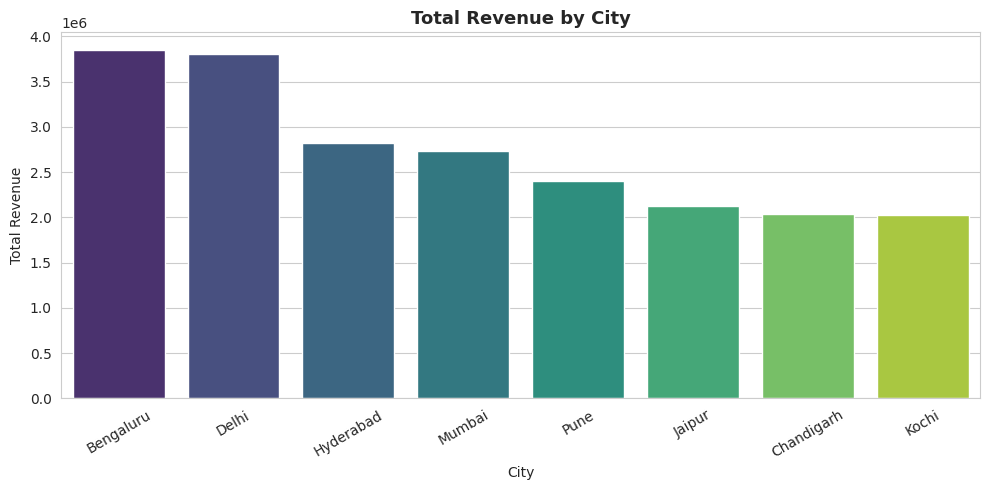

In [5]:
city_revenue = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values, hue=city_revenue.index,
            palette="viridis", legend=False)
plt.title("Total Revenue by City", fontsize=13, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:** Revenue is not evenly distributed across cities — a handful of cities contribute disproportionately more to total revenue. This highlights which markets are currently the strongest and could guide where to focus marketing or operational investment.

## 4. Average Rating by Cuisine (Bar Chart)

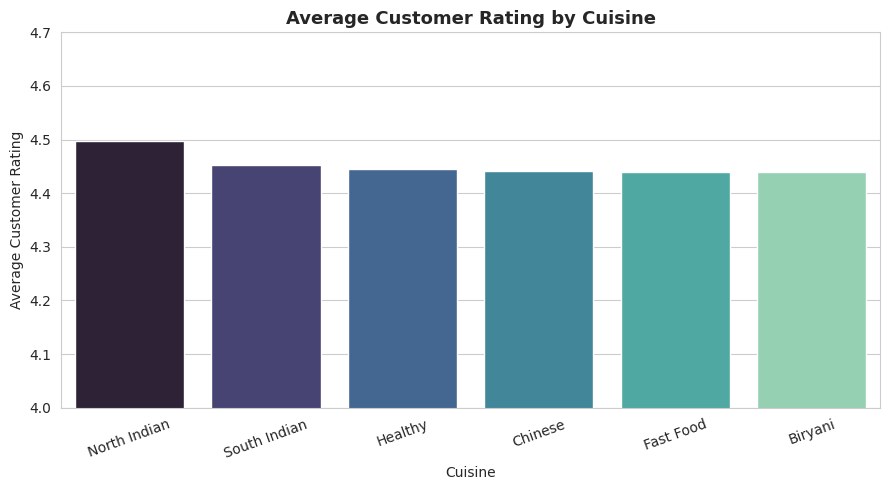

In [6]:
cuisine_rating = df.groupby("Cuisine")["Customer_Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=cuisine_rating.index, y=cuisine_rating.values, hue=cuisine_rating.index,
            palette="mako", legend=False)
plt.title("Average Customer Rating by Cuisine", fontsize=13, fontweight="bold")
plt.xlabel("Cuisine")
plt.ylabel("Average Customer Rating")
plt.ylim(4.0, 4.7)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** Average ratings are fairly close across cuisines (note the zoomed y-axis), but small consistent differences can still reveal which cuisines tend to satisfy customers most — useful for menu or partner-restaurant prioritization.

## 5. Marketing Spend vs. Revenue (Scatter Plot)

A scatter plot reveals the relationship between two continuous variables — here, whether higher marketing spend is associated with higher revenue.

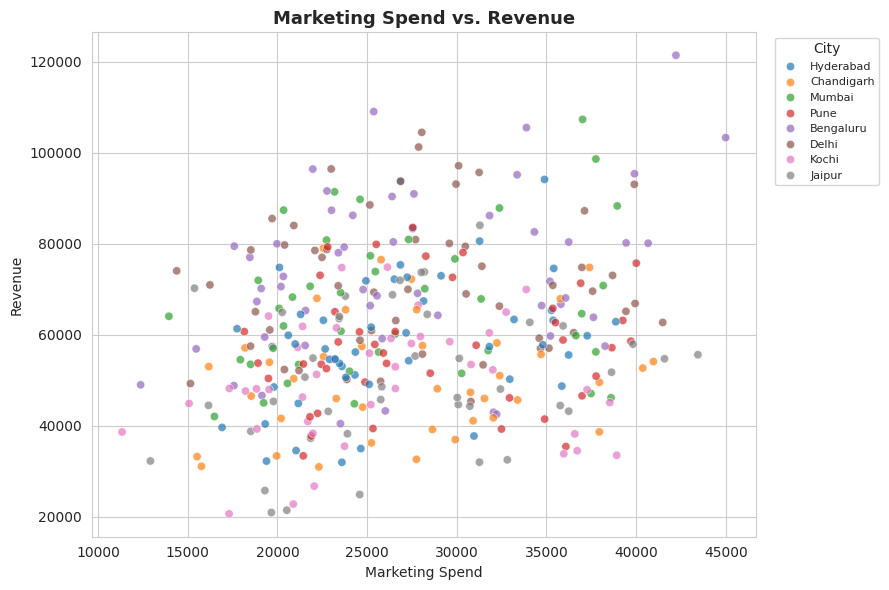

In [7]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Marketing_Spend", y="Revenue", hue="City", alpha=0.7, palette="tab10")
plt.title("Marketing Spend vs. Revenue", fontsize=13, fontweight="bold")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
correlation = df["Marketing_Spend"].corr(df["Revenue"])
print(f"Correlation between Marketing Spend and Revenue: {correlation:.3f}")

Correlation between Marketing Spend and Revenue: 0.198


**Interpretation:** There is a slight upward trend, but the points are widely scattered — the correlation value above confirms this is a **weak** relationship. Marketing spend alone does not strongly predict revenue in this dataset; other factors (like order volume and average order value) play a bigger role, as the later correlation heatmap confirms.

## 6. Delivery Time vs. Customer Rating (Scatter Plot)

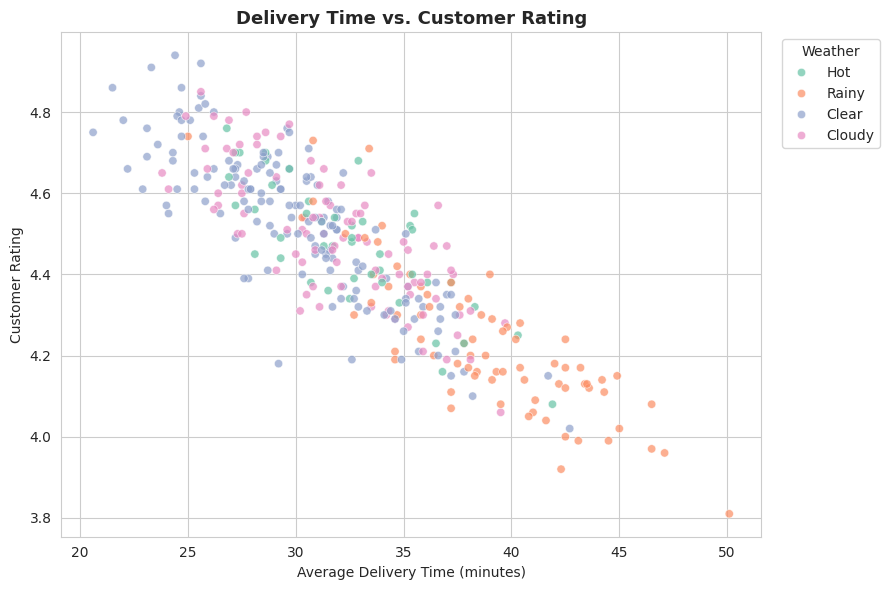

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Avg_Delivery_Minutes", y="Customer_Rating",
                 hue="Weather", alpha=0.7, palette="Set2")
plt.title("Delivery Time vs. Customer Rating", fontsize=13, fontweight="bold")
plt.xlabel("Average Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.legend(title="Weather", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
correlation_delivery = df["Avg_Delivery_Minutes"].corr(df["Customer_Rating"])
print(f"Correlation between Delivery Time and Customer Rating: {correlation_delivery:.3f}")

Correlation between Delivery Time and Customer Rating: -0.876


**Interpretation:** There's a clear, steep downward trend — the correlation value above confirms this is a **strong** negative relationship. As delivery time increases, customer ratings drop sharply, making delivery speed the single most influential factor behind customer satisfaction found anywhere in this dataset.

## 7. Distribution of Average Order Value (Histogram)

A histogram shows the shape of a single variable's distribution — here, how order values are spread out.

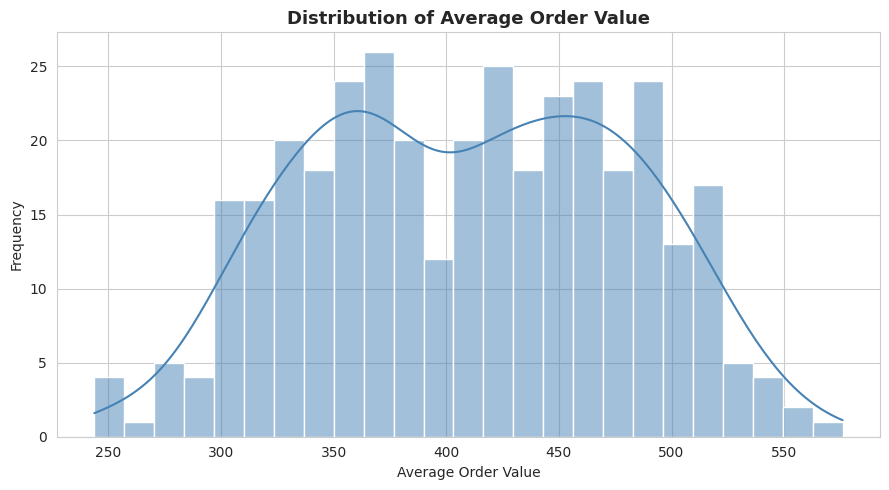

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Average_Order_Value"], bins=25, kde=True, color="steelblue")
plt.title("Distribution of Average Order Value", fontsize=13, fontweight="bold")
plt.xlabel("Average Order Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Average order values are roughly centered around a typical range with a moderate spread, and the distribution appears reasonably symmetric (no extreme skew) — meaning most order batches fall within a predictable pricing band rather than being dominated by a few very high or very low outliers.

## 8. Revenue by Order Channel (Box Plot)

A box plot compares the spread and median of a numeric variable across categories, while also making outliers visible.

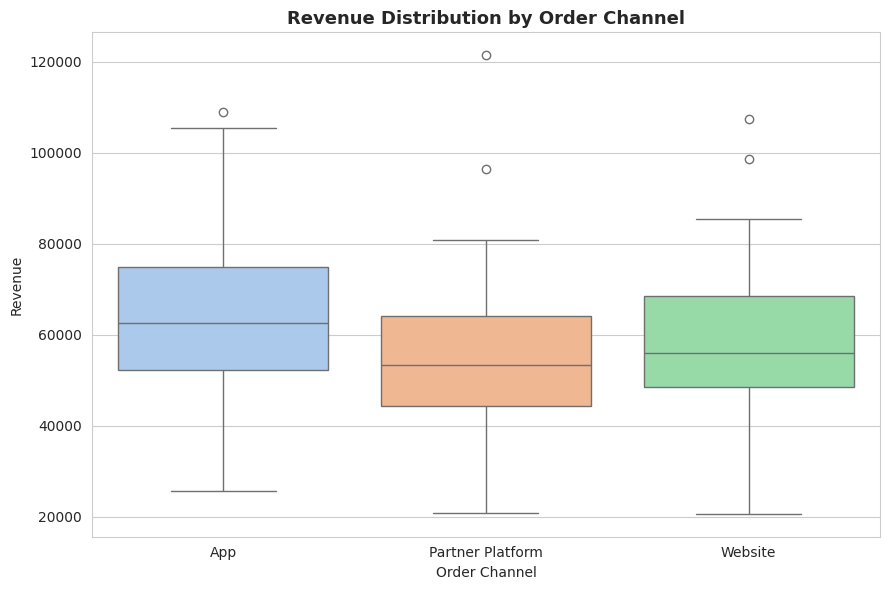

In [12]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Order_Channel", y="Revenue", hue="Order_Channel",
            palette="pastel", legend=False)
plt.title("Revenue Distribution by Order Channel", fontsize=13, fontweight="bold")
plt.xlabel("Order Channel")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Interpretation:** The median and spread of revenue differ across order channels — one channel may consistently generate higher revenue per batch, while another shows more variability (a wider box and more outliers). This helps identify which channel is the more reliable revenue source versus which is more volatile.

## 9. Customer Rating by Weather Condition (Violin Plot)

A violin plot extends the box plot by also showing the full distribution shape (density) of the data, which is useful for spotting multi-modal patterns that a box plot alone would hide.

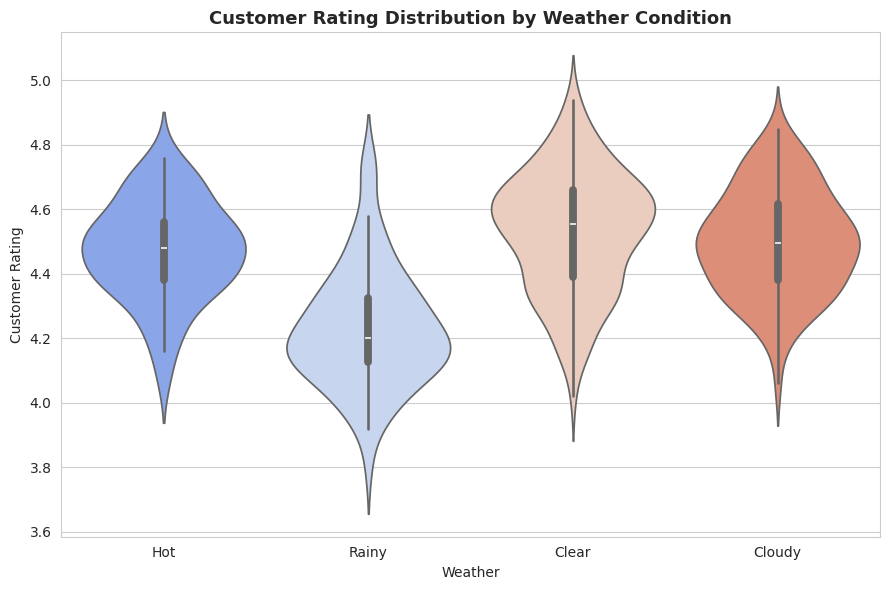

In [13]:
plt.figure(figsize=(9, 6))
sns.violinplot(data=df, x="Weather", y="Customer_Rating", hue="Weather",
               palette="coolwarm", legend=False)
plt.title("Customer Rating Distribution by Weather Condition", fontsize=13, fontweight="bold")
plt.xlabel("Weather")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

**Interpretation:** The shape and spread of customer ratings differ somewhat by weather condition — for instance, Rainy or Hot conditions may show a wider or lower-shifted distribution compared to Clear weather, hinting that adverse weather can weigh on the customer experience (likely via longer delivery times).

## 10. Number of Order Batches by City and Order Channel (Count Plot)

A count plot shows how frequently each category appears, useful for understanding the composition of the dataset itself.

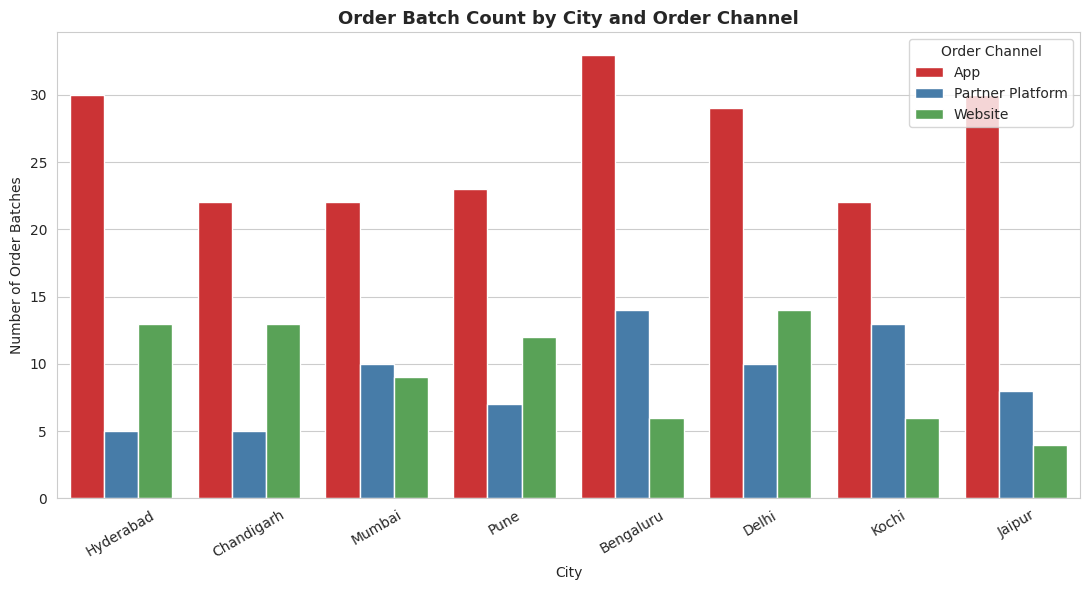

In [14]:
plt.figure(figsize=(11, 6))
sns.countplot(data=df, x="City", hue="Order_Channel", palette="Set1")
plt.title("Order Batch Count by City and Order Channel", fontsize=13, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Number of Order Batches")
plt.xticks(rotation=30)
plt.legend(title="Order Channel")
plt.tight_layout()
plt.show()

**Interpretation:** The App is consistently the most common order channel across nearly every city, while Website and Partner Platform make up a smaller, fairly even share — suggesting the App is the dominant acquisition channel and a natural priority for continued investment.

## 11. Correlation Heatmap of Numeric Variables

A heatmap gives a compact, color-coded overview of how every numeric variable relates to every other — helpful for quickly spotting the strongest relationships in the dataset.

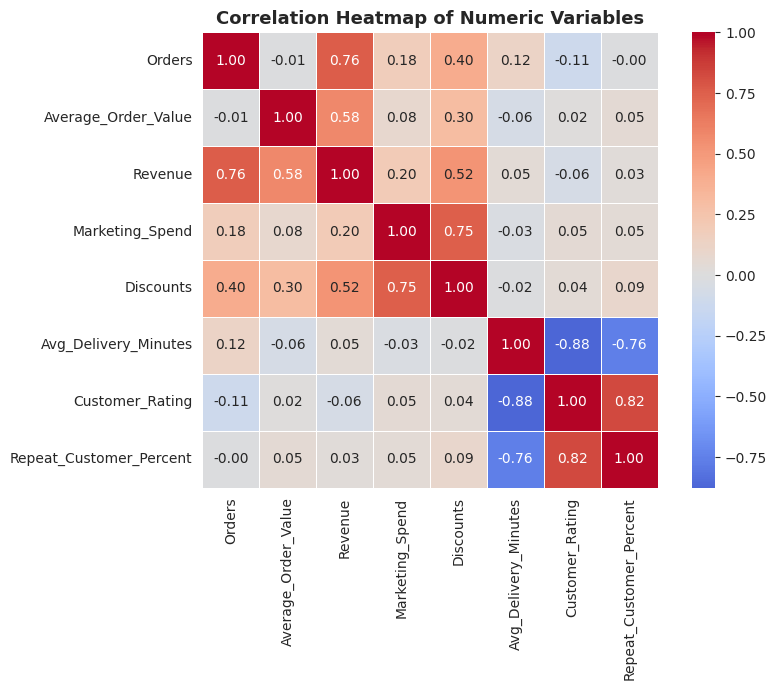

In [15]:
numeric_cols = ["Orders", "Average_Order_Value", "Revenue", "Marketing_Spend",
                "Discounts", "Avg_Delivery_Minutes", "Customer_Rating", "Repeat_Customer_Percent"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Numeric Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** `Revenue` correlates most strongly with `Orders`, followed by `Average_Order_Value` and `Discounts`, while its relationship with `Marketing_Spend` is comparatively weak. `Customer_Rating` shows a very strong negative relationship with `Avg_Delivery_Minutes` and a strong positive relationship with `Repeat_Customer_Percent` — together suggesting that fast delivery drives satisfaction, and satisfaction in turn drives repeat business, more than marketing spend or discounting do.

## 12. Discounts vs. Repeat Customer Percentage (Scatter Plot)

An additional relationship worth checking: do higher discounts correlate with better customer retention (repeat customers)?

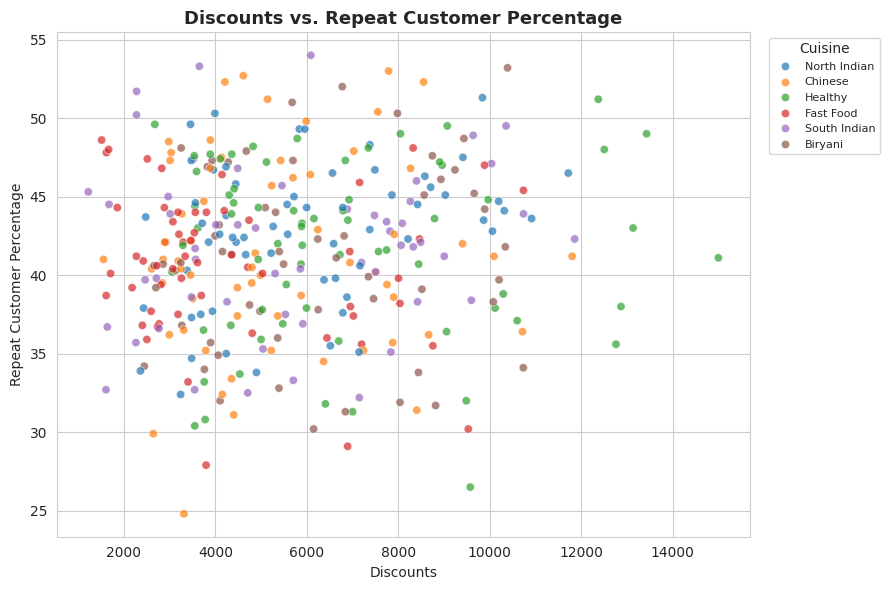

In [16]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Discounts", y="Repeat_Customer_Percent",
                 hue="Cuisine", alpha=0.7, palette="tab10")
plt.title("Discounts vs. Repeat Customer Percentage", fontsize=13, fontweight="bold")
plt.xlabel("Discounts")
plt.ylabel("Repeat Customer Percentage")
plt.legend(title="Cuisine", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
correlation_discount = df["Discounts"].corr(df["Repeat_Customer_Percent"])
print(f"Correlation between Discounts and Repeat Customer %: {correlation_discount:.3f}")

Correlation between Discounts and Repeat Customer %: 0.089


**Interpretation:** The relationship between discounts and repeat customer percentage is weak, suggesting that discounting alone doesn't strongly drive customer loyalty in this dataset — factors like delivery speed and overall experience likely matter more for retention than short-term price incentives.

## 13. Summary of Key Findings

1. **Orders and revenue move together over time**, with no extreme divergence — revenue growth in this dataset is driven primarily by order volume rather than large swings in pricing.

2. **Revenue is concentrated in a handful of cities**, making city-level performance a useful lens for prioritizing marketing or operational investment.

3. **Delivery time is by far the strongest driver of customer satisfaction found in this analysis.** Both the scatter plot and the correlation heatmap show a strong negative relationship between `Avg_Delivery_Minutes` and `Customer_Rating` — far stronger than any other numeric relationship in the dataset.

4. **Customer rating and repeat customer percentage are strongly linked**, reinforcing that a better delivery experience doesn't just improve one-time satisfaction — it likely feeds directly into customer retention as well.

5. **Marketing spend has only a weak relationship with revenue**, weaker than order volume or average order value — suggesting that, on its own, marketing spend is a modest lever compared to operational factors like delivery speed.

6. **Weather appears to affect the customer experience**, with ratings shifting somewhat under Rainy/Hot conditions compared to Clear weather — likely an indirect effect operating through longer delivery times.

7. **The App is the dominant order channel** across virtually every city, while revenue and its variability differ somewhat by channel (per the box plot), suggesting channel-specific strategies could improve consistency.

8. **Discounts show only a weak link to repeat customer percentage**, implying that discounting alone is not an efficient lever for building long-term customer loyalty — delivery speed and overall service quality appear to matter far more for retention than short-term price incentives.